In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import urllib.request

Number of observations: 683
Time range: 5261.6 to 7507.5 days
Magnitude range: 14.242 to 15.068


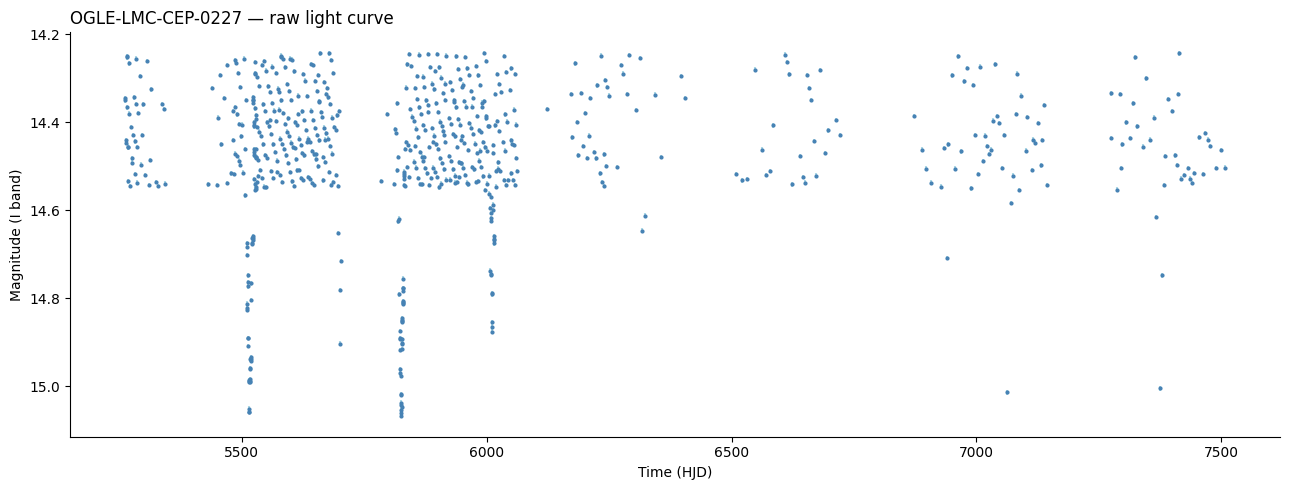

In [3]:
url = "https://ftp.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/cep/phot/I/OGLE-LMC-CEP-0227.dat"
urllib.request.urlretrieve(url, "cep0227.dat")

# load it
data = np.genfromtxt("cep0227.dat")
time = data[:, 0]
magnitude = data[:, 1]
err = data[:, 2]

print(f"Number of observations: {len(time)}")
print(f"Time range: {time.min():.1f} to {time.max():.1f} days")
print(f"Magnitude range: {magnitude.min():.3f} to {magnitude.max():.3f}")

# plot raw light curve
fig, ax = plt.subplots(figsize=(13, 5))
ax.errorbar(time, magnitude, yerr=err, fmt='o', 
            markersize=2, color='steelblue', ecolor='lightblue')
ax.invert_yaxis()  # astronomy convention — brighter = smaller magnitude
ax.set_xlabel('Time (HJD)', fontsize=10)
ax.set_ylabel('Magnitude (I band)', fontsize=10)
ax.set_title('OGLE-LMC-CEP-0227 — raw light curve', fontweight='normal', loc='left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('cep0227_raw.png', dpi=150, bbox_inches='tight')
plt.show()

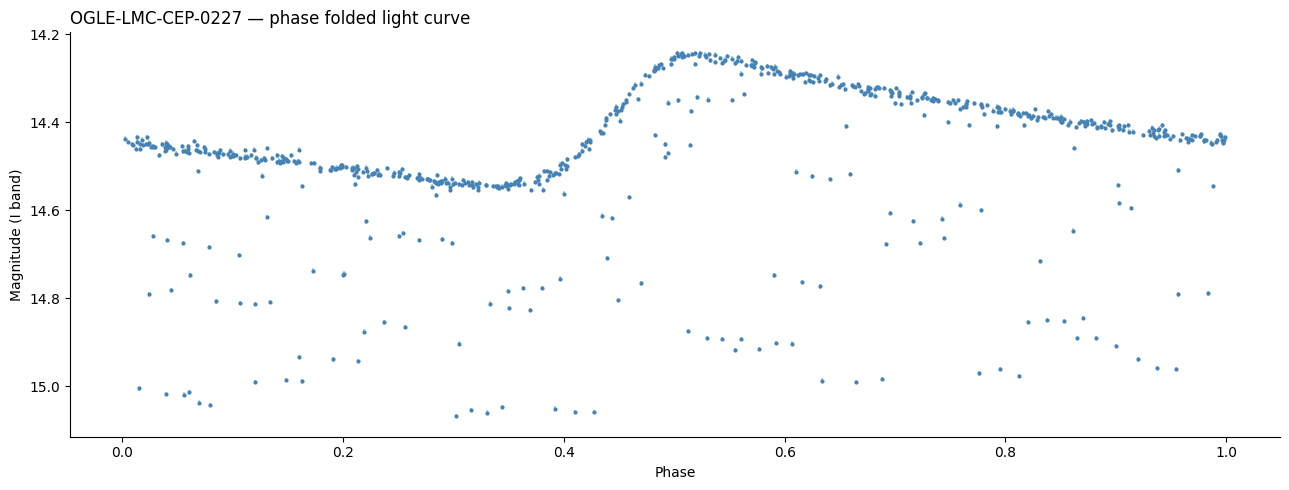

In [4]:
period = 3.797  # days

phase = (time % period) / period

fig, ax = plt.subplots(figsize=(13, 5))
ax.errorbar(phase, magnitude, yerr=err, fmt='o',
            markersize=2, color='steelblue', ecolor='lightblue')
ax.invert_yaxis()
ax.set_xlabel('Phase', fontsize=10)
ax.set_ylabel('Magnitude (I band)', fontsize=10)
ax.set_title('OGLE-LMC-CEP-0227 — phase folded light curve', 
             fontweight='normal', loc='left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('cep0227_phased.png', dpi=150, bbox_inches='tight')
plt.show()

Folded over on period: this pattern repeats itself, one period is 3.787 days!

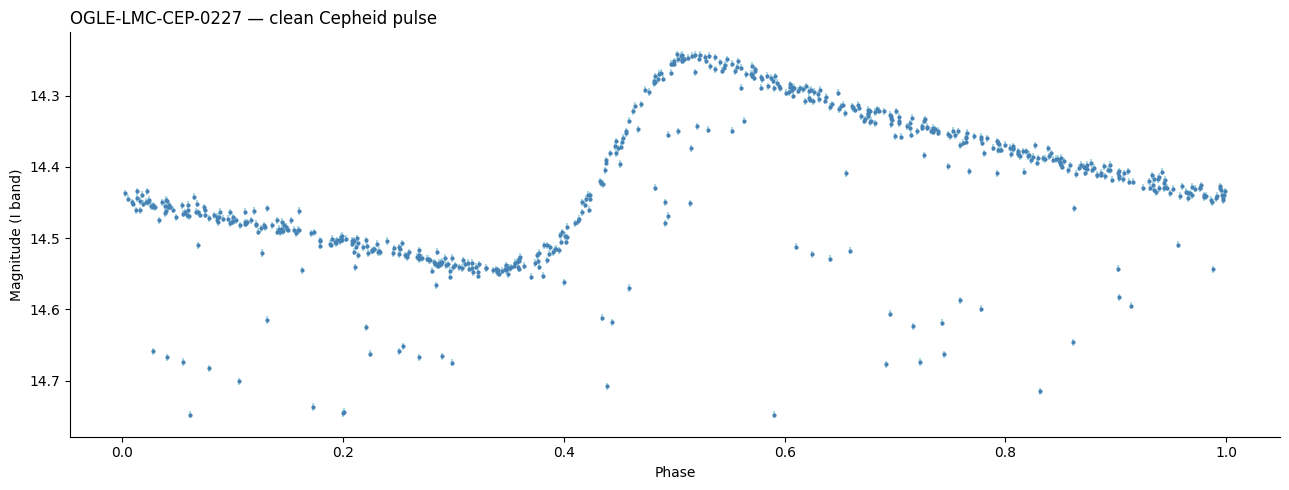

In [5]:
# filter out eclipse points — keep only points within 0.3 mag of the median
median_mag = np.median(magnitude)
mask = np.abs(magnitude - median_mag) < 0.3

time_clean = time[mask]
magnitude_clean = magnitude[mask]
err_clean = err[mask]

phase_clean = (time_clean % period) / period

fig, ax = plt.subplots(figsize=(13, 5))
ax.errorbar(phase_clean, magnitude_clean, yerr=err_clean, fmt='o',
            markersize=2, color='steelblue', ecolor='lightblue')
ax.invert_yaxis()
ax.set_xlabel('Phase', fontsize=10)
ax.set_ylabel('Magnitude (I band)', fontsize=10)
ax.set_title('OGLE-LMC-CEP-0227 — clean Cepheid pulse', 
             fontweight='normal', loc='left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('cep0227_clean.png', dpi=150, bbox_inches='tight')
plt.show()

Cleaned up. Now, we verify levitt's law, with more cepheids. 

In [8]:
url_cat = "https://ftp.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/cep/cepF.dat"
urllib.request.urlretrieve(url_cat, "lmc_cepheids.dat")

cat = np.genfromtxt("lmc_cepheids.dat", usecols=(3, 1), invalid_raise=False)
periods = cat[:, 0]
magnitudes = cat[:, 1]

# remove bad values
mask = np.isfinite(periods) & np.isfinite(magnitudes)
periods = periods[mask]
magnitudes = magnitudes[mask]

print(f"Number of Cepheids: {len(periods)}")
print(f"Period range: {periods.min():.2f} to {periods.max():.2f} days")

Number of Cepheids: 2439
Period range: 0.97 to 34.45 days


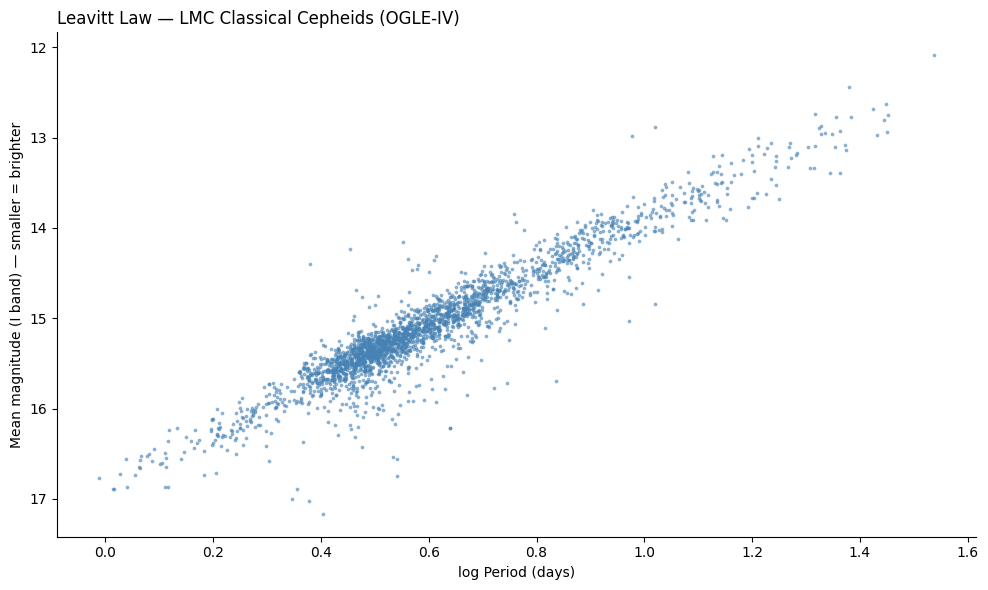

In [11]:
fig, ax = plt.subplots(figsize = (10,6))
ax.scatter(np.log10(periods), magnitudes, 
           s=3, color='steelblue', alpha=0.5)

ax.invert_yaxis()
ax.set_xlabel('log Period (days)', fontsize=10)
ax.set_ylabel('Mean magnitude (I band) — smaller = brighter', fontsize=10)
ax.set_title('Leavitt Law — LMC Classical Cepheids (OGLE-IV)', 
             fontweight='normal', loc='left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('leavitt_law.png', dpi=150, bbox_inches='tight')
plt.show()

Now, we get the slop in kiloparsecs, and see how close we get to the published value! I wonder what different kind of toolkits, people use.

In [16]:
from numpy.polynomial import polynomial as P

log_periods = np.log10(periods)

# linear fit
coeffs = np.polyfit(log_periods,magnitudes, 1)
slope = coeffs[0]
intercept = coeffs [1] #y = ax+b

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"Leavitt law: M = {slope:.4f} x log(P) + {intercept:.4f}")


Slope: -2.9173
Intercept: 16.8436
Leavitt law: M = -2.9173 x log(P) + 16.8436
